--- GEOSPATIAL METADATA ---
File Width (Columns): 6786 pixels
File Height (Rows):   9164 pixels
Number of Bands:      4
Coordinate System:    EPSG:32630
Bounding Box bounds:  BoundingBox(left=821142.1044038694, bottom=637216.44604567, right=824534.9891598072, top=641798.4726216238)
Spatial Transform:
| 0.50, 0.00, 821142.10|
| 0.00,-0.50, 641798.47|
| 0.00, 0.00, 1.00|

Numpy Array Shape for ML Processing: (9164, 6786, 3)

Displaying your satellite image canvas area...


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\rasterio\plot.py:120: NodataShadowWarning: The dataset's nodata attribute is shadowing the alpha band. All masks will be determined by the nodata attribute
  arr = source.read(rgb_indexes, masked=True)


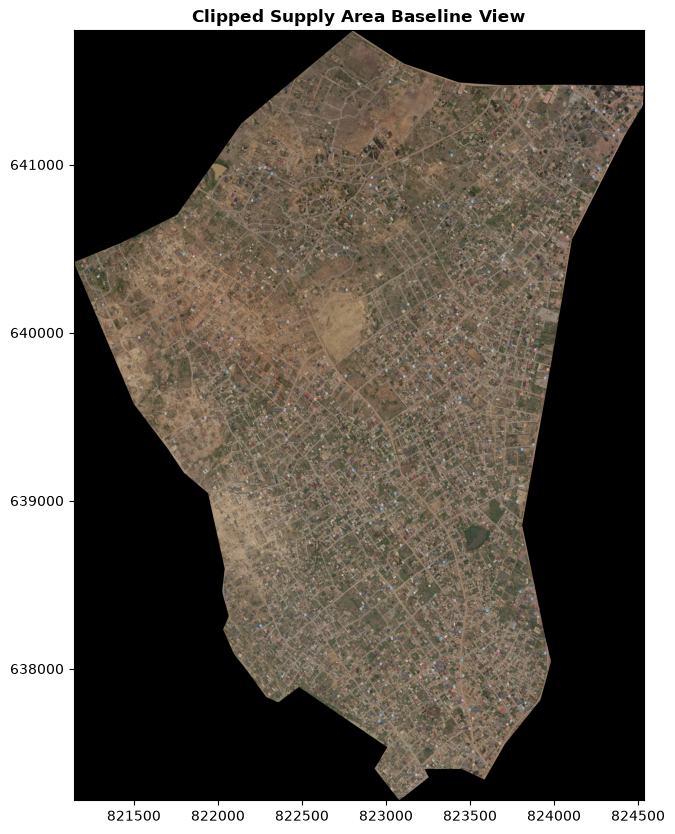

In [1]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the path to your exported QGIS image
# (Replace with the exact path you found in your Layer Properties)
tif_path = "C:/Users/user/Downloads/python_projects/dn_315_supply_image_clipped.tif"

# 2. Open the GeoTIFF file
with rasterio.open(tif_path) as src:
    print("--- GEOSPATIAL METADATA ---")
    print(f"File Width (Columns): {src.width} pixels")
    print(f"File Height (Rows):   {src.height} pixels")
    print(f"Number of Bands:      {src.count}")
    print(f"Coordinate System:    {src.crs}")
    print(f"Bounding Box bounds:  {src.bounds}")
    # The transform matrix contains pixel resolution and top-left anchor coordinates
    print(f"Spatial Transform:\n{src.transform}\n")

    # 3. Read the image bands into memory
    # Satellite imagery usually contains Red (1), Green (2), Blue (3)
    if src.count >= 3:
        # Read bands 1, 2, and 3
        r = src.read(1)
        g = src.read(2)
        b = src.read(3)
        
        # Stack them into a standard (Height, Width, Channels) Numpy array for ML frameworks
        rgb_array = np.dstack((r, g, b))
        print(f"Numpy Array Shape for ML Processing: {rgb_array.shape}")
    else:
        # If it's a single band image (grayscale/index)
        single_band = src.read(1)
        print(f"Single Band Array Shape: {single_band.shape}")

    # 4. Plot the image using rasterio's geo-aware plotting tool
    print("\nDisplaying your satellite image canvas area...")
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 'show' automatically maintains spatial coordinate axes (UTM Easting/Northing)
    show(src, ax=ax, title="Clipped Supply Area Baseline View")
    plt.show()
